# Subcategory Classifier

## Run this notebook to train the model, then save it for use in classification.py

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras import Sequential, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import sys
sys.path.append('..')
from shoppingassistant.helper_functions import load_images_and_labels, split_train_val

### 0. Combine categories

In [ ]:
df = pd.read_csv('../raw_data/articles_filtered.csv')

category_mapping = {
    'Heeled sandals': 'Heels',
    'Flat shoes': 'Flat shoe',
    'Moccasins': 'Flat shoe',
    'Bootie': 'Boots',
    'Pre-walkers': 'Boots',
}

df['product_type_name'] = df['product_type_name'].replace(category_mapping)
df.to_csv('../raw_data/articles_filtered_combined.csv', index=False)

### 1. Load all images and labels

In [ ]:
X, y, categories = load_images_and_labels(
    target_column='product_type_name',
    num_images=None  # None = all images, or set to 100 for testing
)

print(f"\nCategories: {categories}")
print(f"Number of categories: {len(categories)}")

Using all 5156 images
Categories (16): ['Ballerinas', 'Bootie', 'Boots', 'Flat shoe', 'Flat shoes', 'Flip flop', 'Heeled sandals', 'Heels', 'Moccasins', 'Other shoe', 'Pre-walkers', 'Pumps', 'Sandals', 'Slippers', 'Sneakers', 'Wedge']
 Loaded 5156 images
 X shape: (5156, 256, 256, 3)
 y shape: (5156,)

Categories: ['Ballerinas', 'Bootie', 'Boots', 'Flat shoe', 'Flat shoes', 'Flip flop', 'Heeled sandals', 'Heels', 'Moccasins', 'Other shoe', 'Pre-walkers', 'Pumps', 'Sandals', 'Slippers', 'Sneakers', 'Wedge']
Number of categories: 16


### 2. One-hot encode labels

In [3]:
y_encoded = to_categorical(y, num_classes=len(categories))
print(f"Labels shape after encoding: {y_encoded.shape}")

Labels shape after encoding: (5156, 16)


### 3. Split into train/validation

In [ ]:
X_train, X_val, y_train, y_val = split_train_val(X, y_encoded, test_size=0.2) # by defauls 0.2

Training set: 4124 images (80%)
Validation set: 1032 images (20%)


### 4. Build model 

In [5]:
model = Sequential()
model.add(layers.Conv2D(16, (4, 4), padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(len(categories), activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model built and compiled")
model.summary()


Model built and compiled


/Users/meerimburkanova/.pyenv/versions/3.10.6/envs/shoppingassistant-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 573,488 (2.19 MB)

 Trainable params: 573,488 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Train model

In [ ]:
es = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='../models/subcategory_classifier_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[es, model_checkpoint],
    verbose=1
)

print(f"Best epoch: {es.stopped_epoch - es.patience + 1}")
print(f"Best model saved at: ../models/subcategory_classifier_best.keras")

Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3052 - loss: 2.1855
Epoch 1: val_accuracy improved from None to 0.40407, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 403ms/step - accuracy: 0.3426 - loss: 2.0732 - val_accuracy: 0.4041 - val_loss: 1.9656
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.3929 - loss: 1.9051
Epoch 2: val_accuracy improved from 0.40407 to 0.44671, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 50s 389ms/step - accuracy: 0.4127 - loss: 1.8583 - val_accuracy: 0.4467 - val_loss: 1.7642
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.4861 - loss: 1.6568
Epoch 3: val_accuracy improved from 0.44671 to 0.52616, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 54s 418ms/step - accuracy: 0.4993 - loss: 1.6098 - val_accuracy: 0.5262 - val_loss: 1.5715
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5590 - loss: 1.4090
Epoch 4: val_accuracy improved from 0.52616 to 0.55523, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - accuracy: 0.5580 - loss: 1.4127 - val_accuracy: 0.5552 - val_loss: 1.4524
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.5959 - loss: 1.2545
Epoch 5: val_accuracy improved from 0.55523 to 0.59884, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - accuracy: 0.6140 - loss: 1.2266 - val_accuracy: 0.5988 - val_loss: 1.3873
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.6374 - loss: 1.1188
Epoch 6: val_accuracy improved from 0.59884 to 0.61240, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 62s 483ms/step - accuracy: 0.6275 - loss: 1.1223 - val_accuracy: 0.6124 - val_loss: 1.2842
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.6921 - loss: 0.9560
Epoch 7: val_accuracy did not improve from 0.61240
129/129 ━━━━━━━━━━━━━━━━━━━━ 69s 532ms/step - accuracy: 0.6826 - loss: 0.9865 - val_accuracy: 0.6095 - val_loss: 1.2740
Epoch 8/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7192 - loss: 0.8670
Epoch 8: val_accuracy improved from 0.61240 to 0.62694, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 499ms/step - accuracy: 0.7153 - loss: 0.8833 - val_accuracy: 0.6269 - val_loss: 1.2847
Epoch 9/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7474 - loss: 0.7798
Epoch 9: val_accuracy improved from 0.62694 to 0.63953, saving model to ../models/subcategory_classifier_best.h5


129/129 ━━━━━━━━━━━━━━━━━━━━ 63s 485ms/step - accuracy: 0.7430 - loss: 0.7815 - val_accuracy: 0.6395 - val_loss: 1.2985
Epoch 10/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7912 - loss: 0.6354
Epoch 10: val_accuracy did not improve from 0.63953
129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 501ms/step - accuracy: 0.7839 - loss: 0.6440 - val_accuracy: 0.6153 - val_loss: 1.4509
Epoch 11/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8171 - loss: 0.5712
Epoch 11: val_accuracy did not improve from 0.63953
129/129 ━━━━━━━━━━━━━━━━━━━━ 64s 496ms/step - accuracy: 0.8099 - loss: 0.5794 - val_accuracy: 0.6202 - val_loss: 1.4285
Epoch 12/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8335 - loss: 0.4893
Epoch 12: val_accuracy did not improve from 0.63953
129/129 ━━━━━━━━━━━━━━━━━━━━ 63s 485ms/step - accuracy: 0.8252 - loss: 0.5174 - val_accuracy: 0.6240 - val_loss: 1.6694
Epoch 13/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8500 - loss: 0.4569
Epoch 13

NameError: name 'early_stopping' is not defined

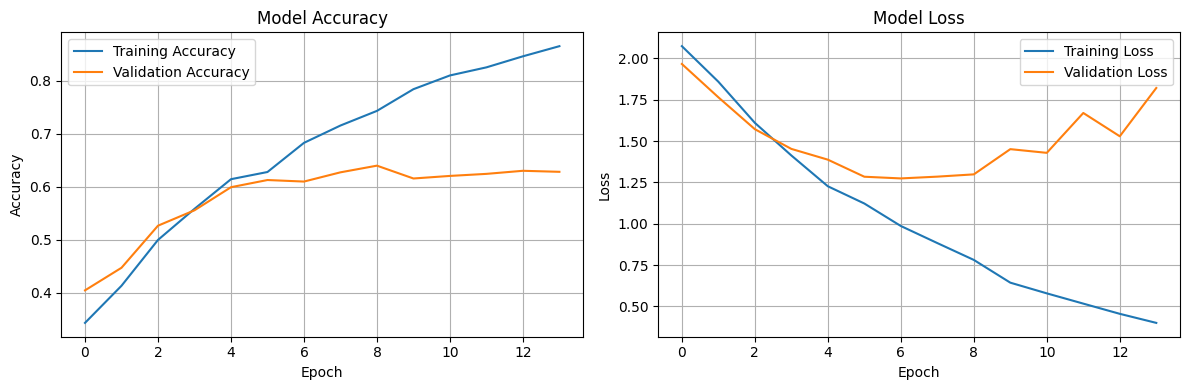

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 6.1 Test prediction from our own data

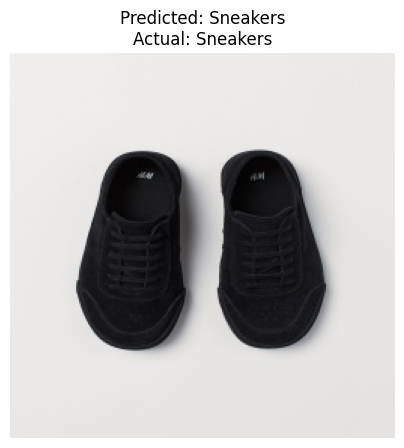

In [ ]:
test_image = X_val[0:1]
prediction = model.predict(test_image, verbose=0)
predicted_idx = np.argmax(prediction[0])
predicted_category = categories[predicted_idx]
actual_idx = np.argmax(y_val[0])
actual_category = categories[actual_idx]

# Display the test image
test_image = X_val[0]
plt.figure(figsize=(5, 5))
plt.imshow(test_image)
plt.title(f"Predicted: {predicted_category}\nActual: {actual_category}")
plt.axis('off')
plt.show()

### 6.1 Test prediction from random shoe from the web

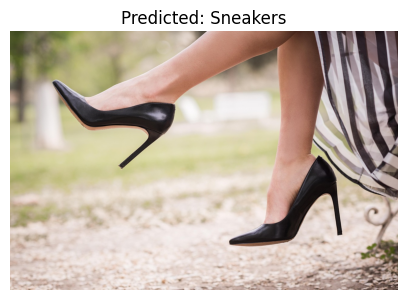

Prediction: Sneakers


In [14]:
import requests
from PIL import Image
from io import BytesIO

url = "https://cdn.pixabay.com/photo/2017/07/25/14/50/shoes-2538424_1280.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

img.save("test_web_shoe.jpg")

from shoppingassistant.helper_functions import preprocess_single_image
img_array = preprocess_single_image("test_web_shoe.jpg")
prediction = model.predict(img_array, verbose=0)
predicted_idx = np.argmax(prediction[0])
predicted_category = categories[predicted_idx]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Predicted: {predicted_category}")
plt.axis('off')
plt.show()

print(f"Prediction: {predicted_category}")

### 7. How to use the saved model

In [ ]:
# In classification.py, load and use like this:

# from tensorflow.keras.models import load_model
# from classification import classify_subcategory

# Load the trained model:
# model = load_model('../models/subcategory_classifier.h5')

# Classify new image:
# result = classify_subcategory('customer_shoe.jpg', model)
# print(f"Category: {result}")